In [1]:
from langchain_community.utilities import SerpAPIWrapper
from dotenv import load_dotenv
import os
from langchain_core.tools import Tool

load_dotenv()
os.environ["SERPAPI_API_KEY"]=os.getenv("SERPAPI_API_KEY")

# Initialize the wrapper. It will use the SERPAPI_API_KEY environment variable.
search_wrapper = SerpAPIWrapper(params={'engine': 'google'})



search = Tool(
    name="google_search",
    description="Search Google for current information. Use this for questions about recent events, news, or facts.",
    func=search_wrapper.run
)


In [2]:
# load librarys
from typing_extensions import TypedDict
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
import streamlit as st
from typing import Annotated
from langgraph.graph.message import add_messages
import os
from dotenv import load_dotenv
#from tools import search
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


#load llm and his key
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
llm_groq=ChatGroq(model="openai/gpt-oss-20b")

## Reducers and creating state
class State(TypedDict):
    messages:Annotated[list,add_messages]


#initiating tools

tools=[search]
llm_with_tools=llm_groq.bind_tools(tools)
#functions for llms
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}


def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


# initiating state
graph=StateGraph(State)

## node
#graph.add_node("SuperBot",superbot)
graph.add_node("tool_calling_llm", tool_calling_llm)
graph.add_node("tools", ToolNode(tools))
## Edges

graph.add_edge(START, "tool_calling_llm")
graph.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)
graph.add_edge("tools", END)


graph_builder=graph.compile()

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [3]:
test_message="what is the la liga s matchs"
result=graph_builder.invoke({'messages': HumanMessage(content=test_message)})

In [4]:
result

{'messages': [HumanMessage(content='what is the la liga s matchs', additional_kwargs={}, response_metadata={}, id='7863df2e-b24e-4ab4-b1d0-73bd3d93eacd'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "what is the la liga s matchs". Likely they want current La Liga matches schedule. Need to search. Use google_search.', 'tool_calls': [{'id': 'fc_8d03f4c9-c29d-474e-8cc6-36ce4206f9f5', 'function': {'arguments': '{"__arg1":"La Liga matches today"}', 'name': 'google_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 146, 'total_tokens': 205, 'completion_time': 0.062587807, 'completion_tokens_details': {'reasoning_tokens': 31}, 'prompt_time': 0.009990568, 'prompt_tokens_details': None, 'queue_time': 0.003059462, 'total_time': 0.072578375}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_565badff47', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provide

In [5]:
len(result["messages"])

3

In [6]:
result["messages"][2]

ToolMessage(content='{"title": "LaLiga", "rankings": "Matchday 26 of 38", "thumbnail": "https://serpapi.com/searches/69a448bf95e950f416d169ae/images/IBxaU7WI29MM1RAEWtCZ9Rkxiwp8_4m1gSjM0-6nvpQ.png", "games": [{"tournament": "LaLiga", "venue": "Manuel Martínez Valero", "venue_kgmid": "/m/09x2m4", "status": "Live49\'", "video_highlights": {"link": "https://stories.laliga.com/games/69a439a1ed4a146bcd381b71.html", "thumbnail": "https://serpapi.com/searches/69a448bf95e950f416d169ae/images/kw1kVHOJVD7L4e9cfhZ01r8SxXDskcSPIHrqe8h5Dl0fPhzOKChtdrhcqDYdz17PYUaMGYaOYsojXt40zEm_lA.jpeg"}, "teams": [{"name": "Elche", "score": "1", "kgmid": "/m/06vv_6"}, {"name": "Espanyol", "score": "1", "kgmid": "/m/025txtg"}]}, {"tournament": "LaLiga", "venue": "Mestalla", "venue_kgmid": "/m/069nqf", "date": "Today", "time": "10:15 a.m.", "video_highlights": {"link": "https://stories.laliga.com/games/69a196704f0cc4417c274c5a.html", "thumbnail": "https://serpapi.com/searches/69a448bf95e950f416d169ae/images/kw1kVHO

In [7]:
if result["messages"][2]:
    print("tool available")
else:
    print("no tools")

tool available


In [8]:
result.get("ToolMessage")

In [9]:
result["messages"][2].name

'google_search'

In [10]:
if result["messages"][2]:
    print("tool available")
    result["messages"][2].name
else:
    print("no tools")
    result["messages"][-1].content

tool available


In [11]:
result["messages"]

[HumanMessage(content='what is the la liga s matchs', additional_kwargs={}, response_metadata={}, id='7863df2e-b24e-4ab4-b1d0-73bd3d93eacd'),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "what is the la liga s matchs". Likely they want current La Liga matches schedule. Need to search. Use google_search.', 'tool_calls': [{'id': 'fc_8d03f4c9-c29d-474e-8cc6-36ce4206f9f5', 'function': {'arguments': '{"__arg1":"La Liga matches today"}', 'name': 'google_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 146, 'total_tokens': 205, 'completion_time': 0.062587807, 'completion_tokens_details': {'reasoning_tokens': 31}, 'prompt_time': 0.009990568, 'prompt_tokens_details': None, 'queue_time': 0.003059462, 'total_time': 0.072578375}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_565badff47', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, i

In [13]:
result["messages"][-1].tool_calls

AttributeError: 'ToolMessage' object has no attribute 'tool_calls'

In [14]:
if result["messages"][-1].tool_calls==[]:
    print("no tools")
    result["messages"][-1].content
else:
    print(" tools called ")
    result["messages"][-1].content

AttributeError: 'ToolMessage' object has no attribute 'tool_calls'

In [15]:
test_message="what is the last news give me one"

In [16]:
# After getting the result from graph_builder.invoke()
result = graph_builder.invoke({'messages': test_message})

# Check if the last message has tool calls
if result["messages"][1].tool_calls:
    print("🔧 Tools were called")
    # Loop through all tool calls
    for tool_call in result["messages"][1].tool_calls:
        print(f"   - Tool name: {tool_call['name']}")
    # Get the content (might be empty if tools were called)
    print(f"\n📝 Response: {result['messages'][-1].content}")
else:
    print("🤖 Source: LLM (no tools used)")
    print(f"📝 Response: {result['messages'][-1].content}")

🔧 Tools were called
   - Tool name: google_search

📝 Response: [{"title": "Iran and Israel launch fresh attacks after Iran's Supreme Leader Khamenei killed", "link": "https://www.bbc.com/news/live/cn5ge95q6y7t", "source": "BBC", "source_logo": "https://serpapi.com/searches/69a448d773d175a5ead09ff0/images/_zQ-yq9s1IlsYfLzt01Gk32AIZM0l_uF2SIOvY43RJw.png", "date": "3 minutes ago", "live": true}, {"title": "As the U.S. and Israel attack Iran, governments around the world stress risks of new war in the Middle East", "link": "https://www.cbsnews.com/news/us-israel-attack-iran-world-reaction-to-war-middle-east/", "source": "CBS News", "source_logo": "https://serpapi.com/searches/69a448d773d175a5ead09ff0/images/GIpbFK_N1gX7czSjot3DlnU7L1V4uWt-LPP9VAmlvXY.png", "date": "2 hours ago"}, {"title": "Live updates: Iran lashes out with missiles, prepares for Khamenei funeral on Day 2 of war with U.S., Israel", "link": "https://www.cbsnews.com/live-updates/us-iran-war-israel-supreme-leader-khamenei-fu

In [17]:
result["messages"]

[HumanMessage(content='what is the last news give me one', additional_kwargs={}, response_metadata={}, id='726e8381-e231-41dd-8d81-eb4989176964'),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "what is the last news give me one". They want the latest news. We need to search Google for current information. Use the google_search function.', 'tool_calls': [{'id': 'fc_e6f40e69-f1d2-4499-8163-e41b9be27c06', 'function': {'arguments': '{"__arg1":"latest news"}', 'name': 'google_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 147, 'total_tokens': 209, 'completion_time': 0.071442591, 'completion_tokens_details': {'reasoning_tokens': 36}, 'prompt_time': 0.009852751, 'prompt_tokens_details': None, 'queue_time': 9.035038912, 'total_time': 0.081295342}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_d3e146e1a5', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, '

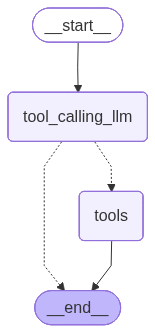

In [18]:
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [19]:
from langchain_core.messages import AIMessage, HumanMessage,SystemMessage
prompt="your goal is to take a raw text response and u need to structure informations "

def llm_structring_response(state:State):
    system_message = SystemMessage(content=prompt)
    
    # Combine system message with existing messages
    all_messages = [system_message] + state["messages"]
    return {"messages":[llm_with_tools.invoke(all_messages)]}

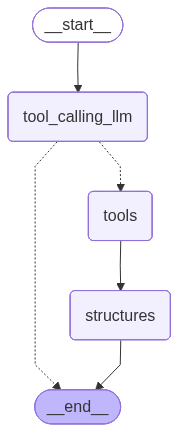

In [20]:
# initiating state
graph=StateGraph(State)

## node
#graph.add_node("SuperBot",superbot)
graph.add_node("tool_calling_llm", tool_calling_llm)
graph.add_node("tools", ToolNode(tools))
graph.add_node("structures", llm_structring_response)

## Edges

graph.add_edge(START, "tool_calling_llm")
graph.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)
graph.add_edge("tools", "structures")
graph.add_edge("structures", END)



graph_builder=graph.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [21]:
test_message="what is the gdp of morocco latesst"
result = graph_builder.invoke({'messages': test_message})

In [22]:
result

{'messages': [HumanMessage(content='what is the gdp of morocco latesst', additional_kwargs={}, response_metadata={}, id='ae1b13a2-7db4-4a3c-a2d6-5fb9b9ef4f1c'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "what is the gdp of morocco latesst" presumably meaning "latest" GDP. We need up-to-date info. We should search. Use google_search.', 'tool_calls': [{'id': 'fc_b82496c6-26b1-4873-9221-49fc168773b4', 'function': {'arguments': '{"__arg1":"latest GDP of Morocco 2023"}', 'name': 'google_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 150, 'total_tokens': 221, 'completion_time': 0.077263004, 'completion_tokens_details': {'reasoning_tokens': 40}, 'prompt_time': 0.009390707, 'prompt_tokens_details': None, 'queue_time': 0.059125792, 'total_time': 0.086653711}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_9340e7d14d', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'lo

In [23]:
# Check if the last message has tool calls
if result["messages"][1].tool_calls:
    print("🔧 Tools were called")
    # Loop through all tool calls
    for tool_call in result["messages"][1].tool_calls:
        print(f"   - Tool name: {tool_call['name']}")
    # Get the content (might be empty if tools were called)
    print(f"\n📝 Response: {result['messages'][-1].content}")
else:
    print("🤖 Source: LLM (no tools used)")
    print(f"📝 Response: {result['messages'][-1].content}")

🔧 Tools were called
   - Tool name: google_search

📝 Response: **Latest GDP of Morocco (2024)**  

| Year | GDP (current U.S. dollars) | Growth vs. previous year |
|------|---------------------------|---------------------------|
| **2024** | **$154.43 billion** | +7.1 % (vs. 2023) |
| 2023 | $144.42 billion | +10.3 % (vs. 2022) |

**Key take‑away**  
- Morocco’s economy grew to **$154.43 billion** in 2024, marking the most recent official GDP figure available.  
- The growth rate in 2024 was **7.1 %**, reflecting a rebound after a modest expansion in 2023.


In [24]:
from langchain_community.document_loaders import WebBaseLoader
from bs4 import BeautifulSoup

# Simple approach - let the loader handle it
loader_multiple_pages = WebBaseLoader(
    "https://arxiv.org/abs/1706.03762"
)

docs = loader_multiple_pages.load()
docs[0].metadata.get("title", "No title")

USER_AGENT environment variable not set, consider setting it to identify your requests.


'[1706.03762] Attention Is All You Need'

### RAG FOR CGNC

In [25]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFDirectoryLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface.embeddings import HuggingFaceEmbeddings


# Initialize the embeddings class with a model name
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

### from langchain_cohere import CohereEmbeddings

# Set embeddings
docs=PyPDFDirectoryLoader("data",extract_images=True,).load()
# Split
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=800, chunk_overlap=100
)
doc_splits = text_splitter.split_documents(docs)

# Add to vectorstore
vectorstore=FAISS.from_documents(
    documents=doc_splits,
    embedding=embeddings,
)


retriever=vectorstore.as_retriever()


KeyError: '/Filter'

In [ ]:
docs[0].page_content

'THE INSIDER’S\nGUIDE TO  \nDIGITAL \nMARKETING\nDiscover the 20-page blueprint \nindustry pros use to grow a \nbusiness like yours, online.'

In [26]:
result=retriever.invoke("what is the benifit of web design")

NameError: name 'retriever' is not defined

In [ ]:
len(result)

4

In [ ]:
for i in range (len(result)):
    print("-----------------------------------------------------")
    print(result[i].page_content)

-----------------------------------------------------
20
21
Where to get help
8
Call 1300 41 00 81
webbuzz.com.au
Website & SEO Health Audit
We check the effectiveness of your online marketing.
Get a full website audit and SEO analysis on how your site ranks on 
Google, plus recommendations on where to make improvements.
 
To redeem, email: info@webbuzz.com.au $346 value – yours FREE!
Unit 68, Level 4 
89-97 Jones St
Ultimo NSW 2007
We work with clients all around Australia.
“I’ve really enjoyed working with Webbuzz. It’s 
a genuine partnership. They understand our 
business, they understand our customers, they 
understand what we are trying to achieve.”
Andrew Ford – Heartland Seniors Finance 
www.seniorsfinance.com.au
/webbuzz @webbuzzau
End Notes
9
1. FREE   buyer persona template
https://www.davidmeermanscott.com/hubfs/documents/Marketing_
Strategy_Template.pdf
2. Know Your Customer! Why Profiling Is The 1st Step in  
Business Web Design 
https://webbuzz.com.au/know-your-customer-w

### testing embeding parameters 

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={
        'device': 'cpu',  # Use 'cuda' if GPU available
        'trust_remote_code': False,  # Set to True only for trusted custom models
    },
    encode_kwargs={
        'normalize_embeddings': True,  # CRITICAL: Ensures cosine similarity works properly
        'batch_size': 32,  # Adjust based on your RAM/VRAM
    },
    multi_process=True,  # Set to True if you have multiple GPUs
    cache_folder=None,  # Uses default cache (~/.cache/huggingface/)
)

# Test it
query_embedding = embeddings.embed_query("What is CGNC?")
print(f"Embedding dimension: {len(query_embedding)}")  # 384 for MiniLM

Embedding dimension: 384


In [ ]:
docs=PyPDFDirectoryLoader("data",extract_images=True,).load()
# Split
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=800, chunk_overlap=100
)
doc_splits = text_splitter.split_documents(docs)

# Add to vectorstore
vectorstore=FAISS.from_documents(
    documents=doc_splits,
    embedding=embeddings,
)


retriever=vectorstore.as_retriever()

In [ ]:
result=retriever.invoke("what is the benifit of web design")
for i in range (len(result)):
    print("-----------------------------------------------------")
    print(result[i].page_content)
    

-----------------------------------------------------
20
21
Where to get help
8
Call 1300 41 00 81
webbuzz.com.au
Website & SEO Health Audit
We check the effectiveness of your online marketing.
Get a full website audit and SEO analysis on how your site ranks on 
Google, plus recommendations on where to make improvements.
 
To redeem, email: info@webbuzz.com.au $346 value – yours FREE!
Unit 68, Level 4 
89-97 Jones St
Ultimo NSW 2007
We work with clients all around Australia.
“I’ve really enjoyed working with Webbuzz. It’s 
a genuine partnership. They understand our 
business, they understand our customers, they 
understand what we are trying to achieve.”
Andrew Ford – Heartland Seniors Finance 
www.seniorsfinance.com.au
/webbuzz @webbuzzau
End Notes
9
1. FREE   buyer persona template
https://www.davidmeermanscott.com/hubfs/documents/Marketing_
Strategy_Template.pdf
2. Know Your Customer! Why Profiling Is The 1st Step in  
Business Web Design 
https://webbuzz.com.au/know-your-customer-w

In [ ]:
# initiating state
graph = StateGraph(State)

## Nodes
graph.add_node("tool_calling_llm", tool_calling_llm)
graph.add_node("tools", ToolNode(tools))
graph.add_node("structures", llm_structring_response)

## Edges
graph.add_edge(START, "tool_calling_llm")

# First conditional: from tool_calling_llm
graph.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
    {
        "tools": "tools",
        "__end__": END
    }
    # No name needed for first one - it gets default name
)

# After tools, always go to structures
graph.add_edge("tools", "structures")

# Second conditional: from structures
graph.add_conditional_edges(
    "structures",
    tools_condition,
    {
        "tools": "tools",
        "__end__": END
    }
    # Also no name - LangGraph handles it automatically
)

# Compile
app = graph.compile()

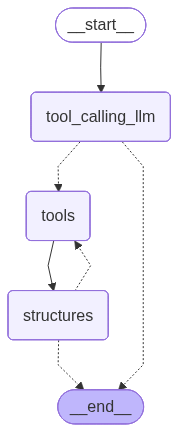

In [ ]:
display(Image(app.get_graph().draw_mermaid_png()))

### advensed with forced using tools

In [ ]:
def agent_structring_response(state:State):
    prompt = """You are a response structuring assistant. Follow these rules strictly:
    
    1. If the response came from 'cgnc_accounting_tool', format it professionally as accounting advice
    2. If the response came from 'google_search', cite the source as "Web Search"
    3. If the response is empty, say "I couldn't find specific information on this topic. Try rephrasing your question."
    4. For accounting questions, always mention that the information comes from CGNC standards
    
    Current response to structure: {response}
    """
    
    # Get the last AI message content
    last_response = state["messages"][-1].content if state["messages"] else ""
    formatted_prompt = prompt.replace("{response}", last_response)
    system_message = SystemMessage(content=formatted_prompt)
    
    # Combine system message with existing messages
    all_messages = [system_message] + state["messages"]
    return {"messages":[llm_with_tools.invoke(all_messages)]}

def route_by_keyword(state: State) -> dict:
    """Pre-process to force accounting tool for relevant queries"""
    last_message = state["messages"][-1].content.lower() if state["messages"] else ""
    
    # Check for accounting keywords
    accounting_keywords = ["cgnc", "comptabilité", "accounting", "maroc", "morocco", 
                          "financial", "tax", "fiscal", "amortissement", "bilan"]
    
    if any(keyword in last_message for keyword in accounting_keywords):
        # Force the model to use accounting tool
        forced_prompt = """IMPORTANT: This is an accounting question about Morocco. 
        You MUST use the 'cgnc_accounting_tool' to answer this question.
        Do not use any other tool until you've tried this one.
        
        Question: {question}"""
        formatted_prompt=forced_prompt.replace("{question}", last_message)
        system_message = SystemMessage(content=formatted_prompt)
        return {"messages": [system_message] + state["messages"]}
    
    return state

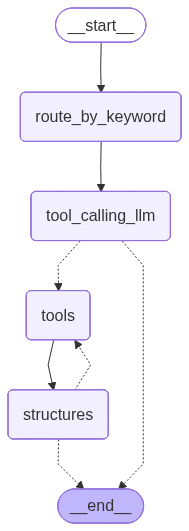

In [ ]:
graph = StateGraph(State)

## Nodes
graph.add_node("tool_calling_llm", tool_calling_llm)
graph.add_node("tools", ToolNode(tools))
graph.add_node("structures", agent_structring_response)
graph.add_node("route_by_keyword", route_by_keyword)

## Edges
graph.add_edge(START, "route_by_keyword")
graph.add_edge("route_by_keyword", "tool_calling_llm")

# First conditional: from tool_calling_llm
graph.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
    {
        "tools": "tools",
        "__end__": END
    }
)

# After tools, always go to structures
graph.add_edge("tools", "structures")

# Second conditional: from structures
graph.add_conditional_edges(
    "structures",
    tools_condition,
    {
        "tools": "tools",
        "__end__": END
    }
)

# Compile
graph=graph.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

### test the pipeline and tool caling

In [27]:
# classess
from langchain_community.document_loaders import PyPDFDirectoryLoader
from logger.logger import get_logger
from exception.custom_exception import CustomException

logging=get_logger(__name__)



class DocumentLoader:
    def __init__(self,directory:str,extract_images:bool=False):
        self.directory=directory
        self.extract_images=extract_images
        logging.info("initialized docuemnt loader")

    def document_loader(self):
        rew_documents=PyPDFDirectoryLoader(self.directory,extract_images=self.extract_images)
        self.docs=rew_documents.load()
        if self.docs:
            try:
                pdf_files = set()
                for doc in self.docs:
                    source = doc.metadata.get('source', 'unknown')
                    pdf_files.add(source)
                # Log each PDF file
                logging.info(f"✅ Successfully loaded {len(self.docs)} documents from {len(pdf_files)} PDF files:")
                for pdf in pdf_files:
                    logging.info(f" 📄 {pdf}")
            except Exception as e:
                    logging.error(f"error in loading documents : {e}")
                    raise CustomException(
                        message=f"Failed to load documents {e}",
                        error_detail=e
                    )
        elif not self.docs:
            logging.warning(f"⚠️ No documents found in {self.directory}")
            print(f"⚠️ No documents found in {self.directory}")
            return []
         
        return self.docs
    
    def get_document_count(self):
        """Get number of documents in directory without loading them"""
        try:
            loader = PyPDFDirectoryLoader(self.directory, extract_images=self.extract_images)
            docs = loader.load()
            return f"documents count : {len(docs)}"
        except Exception as e:
            logging.warning(f"Could not get document count: {e}")
            return 0

##################################################################

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFDirectoryLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from exception.custom_exception import CustomException
from logger.logger import get_logger
logging=get_logger(__name__)

class Embeddings:

    def __init__(self,
        model_name:str="sentence-transformers/all-MiniLM-L6-v2",
        device: str = "cpu",
        normalize_embeddings: bool = True,
        batch_size: int = 32):

        self.model_name = model_name
        self.device = device
        self.normalize_embeddings = normalize_embeddings
        self.batch_size = batch_size
        self._embeddings = None
        logging.info("embedding get initialized")


    def initializing_embedding(self):
        if self._embeddings is None:
            try:
                self.embeddings = HuggingFaceEmbeddings(
                        model_name=self.model_name,
                        model_kwargs={'device': self.device},
                        encode_kwargs={
                            'normalize_embeddings': self.normalize_embeddings,
                            'batch_size': self.batch_size
                        }
                    )
            except Exception as e:
                    logging.error(f"error during initilizing : {e}")
                    raise CustomException(
                        message=f"Failed to initialize embeddings with model {self.model_name} or their is an error in embeding models",
                        error_detail=e
                    )
        return self.embeddings
    
##################################################################

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFDirectoryLoader
from logger.logger import get_logger
from exception.custom_exception import CustomException

logging=get_logger(__name__)



class TextSpliter:
    def __init__(self,chunk_size:int=800,chunk_overlap:int=200,persist_directory:str="vectorestore_VDB"):
        self.chunk_size=chunk_size
        self.chunk_overlap=chunk_overlap
        self.persist_directory=persist_directory
        logging.info(f"✅ TextSplitter initialized with chunk_size={chunk_size}, overlap={chunk_overlap}")


    
    def split_documents(self,documents):
        # Split
        try:
            text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
                chunk_size=self.chunk_size, chunk_overlap=self.chunk_overlap
            )
            chunks = text_splitter.split_documents(documents)
            logging.info(f"✅ Split {len(documents)} documents into {len(chunks)} chunks")
            return chunks
        except Exception as e:
            logging.error(f"❌ Error splitting documents: {e}")
            raise CustomException("Failed to split documents", e)

##################################################

from langchain_chroma import Chroma
from logger.logger import get_logger
from exception.custom_exception import CustomException
from pathlib import Path

logging = get_logger(__name__)

class VectorStore:
    def __init__(self, embeddings, persist_directory):
        self.embeddings = embeddings
        self.persist_directory = persist_directory
        self.vectorstore = None
        Path(persist_directory).mkdir(parents=True, exist_ok=True)
        logging.info(f"✅ VectorStore initialized with persist_dir: {persist_directory}")

    def create_from_documents(self, documents):
        """Create vectorstore from documents"""
        try:
            self.vectorstore = Chroma.from_documents(
                documents=documents,
                embedding=self.embeddings,
                persist_directory=self.persist_directory
            )
            logging.info(f"✅ Created vectorstore with {len(documents)} documents")
            return self.vectorstore
        except Exception as e:
            logging.error(f"❌ Error creating vectorstore: {e}")
            raise CustomException("Failed to create vectorstore", e)

    def load_existing(self):
        """Load existing vectorstore"""
        try:
            self.vectorstore = Chroma(
                embedding_function=self.embeddings,
                persist_directory=self.persist_directory
            )
            logging.info(f"✅ Loaded existing vectorstore from {self.persist_directory}")
            print(f"✅ Loaded existing vectorstore from {self.persist_directory}")
            return self.vectorstore
        except Exception as e:
            logging.error(f"❌ Error loading vectorstore: {e}")
            raise CustomException("Failed to load vectorstore", e)

    def get_retriever(self, k: int = 4):
        """Get retriever from vectorstore"""
        if self.vectorstore is None:
            raise CustomException("Vectorstore not created yet. Call create_from_documents first.")
        return self.vectorstore.as_retriever(search_kwargs={"k": k})
    
#################################################

In [28]:
# pipeline



from src.data_ingestion.documents_loader import DocumentLoader
from src.data_ingestion.embedding import  Embeddings
from src.data_ingestion.text_spliter import TextSpliter
from src.data_ingestion.vectorestore import VectorStore
from pathlib import Path


DATA_DIR = r"C:\Users\VICTUS\Desktop\accountant\data\CGNC"  # Change per file
PERSIST_DIR = "vectorestore\db_CGNC"  # Change per file
FORCE_REBUILD = False  # Set to True only when you want to rebuild

class RagPipeLine:
    def __init__(self,data_dir,persist_dir,force_rebuild,chunk_size,chunk_overlap):
        self.data_dir=data_dir
        self.persist_dir=persist_dir
        self.force_rebuild=force_rebuild
        self.chunk_size=chunk_size
        self.chunk_overlap=chunk_overlap
        self.vectorstore = None  # Initialize as None
        self.retriever = None

        persist_path = Path(self.persist_dir)
        self.vectorstore_exists = (persist_path.exists() and 
                            any(persist_path.glob("*.sqlite3")))  # Chroma files

        print(f"\n{'='*50}")
        print(f"🚀 RAG Pipeline initialized")
        print(f"📂 Data: {self.data_dir}")
        print(f"💾 Persist: {self.persist_dir}")
        print(f"🔍 Vectorstore exists: {self.vectorstore_exists}")
        print(f"{'='*50}\n")
    def run(self):
        embeddings_model=Embeddings()
        embedings=embeddings_model.initializing_embedding()
        self.vectordatabase =VectorStore(embeddings=embedings,
                                persist_directory=self.persist_dir)
        if self.vectorstore_exists and not self.force_rebuild:
            print("🔄 Loading existing vectorstore...")
            self.vectorstore=self.vectordatabase.load_existing() 
            print(f"✅ Loaded existing vectorstore from {self.persist_dir}")

        else:
            document_loader=DocumentLoader(directory=self.data_dir,extract_images=False)
            text_spliter=TextSpliter(chunk_size=self.chunk_size,chunk_overlap=self.chunk_overlap)

            documents=document_loader.document_loader()
            print(f"📄 Loaded {len(documents)} documents from cgnc folder")
            if not documents:
                print("❌ No documents to process. Please add PDF files to data/CGNC/")
                raise ValueError(f"❌ No documents found in {self.data_dir}")
            print("🔤 Embeddings ready")
            chunks =text_spliter.split_documents(documents)
            if not chunks:
                print("❌ No chunks created. Check your PDF files.")
                raise ValueError("❌ No chunks created. Check your PDF files.")
                
            db = self.vectordatabase.create_from_documents(chunks)
            print(f"💾 Vectorstore created with {len(chunks)} documents from cgnc ")
        self.retriever=self.vectordatabase.get_retriever()
        print(f"✅ retriver for {self.persist_dir} is ready to use ")
        return self.retriever


In [29]:
# utils
from src.data_ingestion.documents_loader import DocumentLoader
from src.data_ingestion.embedding import  Embeddings
from src.data_ingestion.text_spliter import TextSpliter
from src.data_ingestion.vectorestore import VectorStore
from pathlib import Path
from src.PipeLine.pipeline import RagPipeLine

DATA_DIR = r"C:\Users\VICTUS\Desktop\accountant\data\CGNC"  # Change per file
PERSIST_DIR = "vectorestore/db_CGNC"  # Change per file
FORCE_REBUILD = False  # Set to True only when you want to rebuild

rag=RagPipeLine(data_dir=DATA_DIR,
            persist_dir=PERSIST_DIR,force_rebuild=False,chunk_size=1000,chunk_overlap=250)
retriever=rag.run()
### Retriever To Retriever Tools
from langchain_classic.tools.retriever import create_retriever_tool

cgnc_tool = create_retriever_tool(
    retriever,
    "cgnc_accounting_tool",  # Simplified name
    """Use this tool for ANY questions about:
    - Moroccan accounting (CGNC - Code Général de Normalisation Comptable)
    - Financial reporting standards in Morocco
    - Moroccan tax accounting rules
    - Chart of accounts (Plan comptable marocain)
    - Accounting treatments specific to Morocco
    - Any question containing words like: CGNC, comptabilité marocaine, Moroccan accounting, Plan comptable
    
    This is your PRIMARY tool for Moroccan accounting questions. ALWAYS use this first for accounting queries."""
)
##################################################################
from src.data_ingestion.documents_loader import DocumentLoader
from src.data_ingestion.embedding import  Embeddings
from src.data_ingestion.text_spliter import TextSpliter
from src.data_ingestion.vectorestore import VectorStore
from src.PipeLine.pipeline import RagPipeLine

DATA_DIR = r"C:\Users\VICTUS\Desktop\accountant\data\LOIS_DE_FINANCE"  # Change per file
PERSIST_DIR = "vectorestore/db_lois_de_finance"  # Change per file
FORCE_REBUILD = False  # Set to True only when you want to rebuild

rag=RagPipeLine(data_dir=DATA_DIR,
            persist_dir=PERSIST_DIR,force_rebuild=False,chunk_size=1000,chunk_overlap=250)
retriever=rag.run()
from langchain_classic.tools.retriever import create_retriever_tool
finance_law_tool = create_retriever_tool(
    retriever,
    "morocco_finance_law_tool",  # Simplified name
    """Use this tool for ANY questions about:
    - Moroccan finance law 
    - Moroccan tax
    - Any question containing words like: law, moroccan finance law, Moroccan lois, 
    
    This is your PRIMARY tool for Moroccan finance law questions. ALWAYS use this first for finance law  queries."""
)

##########################################################

from src.data_ingestion.documents_loader import DocumentLoader
from src.data_ingestion.embedding import  Embeddings
from src.data_ingestion.text_spliter import TextSpliter
from src.data_ingestion.vectorestore import VectorStore
from src.PipeLine.pipeline import RagPipeLine


DATA_DIR = r"C:\Users\VICTUS\Desktop\accountant\data\PLAN_COMPTABLE"  # Change per file
PERSIST_DIR = "vectorestore/db_plan_comptable"  # Change per file
FORCE_REBUILD = False  # Set to True only when you want to rebuild

rag=RagPipeLine(data_dir=DATA_DIR,
            persist_dir=PERSIST_DIR,force_rebuild=False,chunk_size=1000,chunk_overlap=250)
retriever=rag.run()

### Retriever To Retriever Tools
from langchain_classic.tools.retriever import create_retriever_tool
plan_comptable_tool = create_retriever_tool(
    retriever,
    "plan_comptable_tool",  # Simplified name
    """Use this tool to help in accountant operations:
    - Moroccan accounting 
    - les classe de bilan 
    - can work with code general de normalisation comptable to get specefic numbers 
    - use it if you want to comptabilise une facture ou une operation
    - Chart of accounts (Plan comptable marocain)
    - Accounting treatments specific to Morocco
    
    This is your PRIMARY tool for classes comptabilisation questions. ALWAYS use this first to know the classes for comptabilisation des operation queries."""
)


########################################################

from langchain_core.tools import Tool
from langchain_community.document_loaders import WebBaseLoader
from typing import Optional

def web_base_loader(url: str) -> str:
    """
    Load content from a URL and return the page content.
    
    Args:
        url (str): The webpage URL to load
        
    Returns:
        str: The page content or error message
    """
    try:
        loader = WebBaseLoader(url)
        docs = loader.load()
        
        if docs and len(docs) > 0:
            title=docs[0].metadata.get("title")
            content = docs[0].page_content
            return f"Title: {title}\n\nContent: {content}"
        else:
            return "No content found at the provided URL."
            
    except Exception as e:
        return f"Error loading URL: {str(e)}"

# Create the tool
web_loader_tool = Tool(
    name="rag_web_loader",
    description="Loads and reads content from web pages. Input should be a complete URL starting with http:// or https://",
    func=web_base_loader
)

###################################################################

from src.PipeLine.pipeline import RagPipeLine

DATA_DIR = r"C:\Users\VICTUS\Desktop\accountant\data\CGI"  # Change per file
PERSIST_DIR = "vectorestore/db_CGI"  # Change per file
FORCE_REBUILD = False  # Set to True only when you want to rebuild

rag=RagPipeLine(data_dir=DATA_DIR,
            persist_dir=PERSIST_DIR,force_rebuild=False,chunk_size=1000,chunk_overlap=250)

retriever=rag.run()
### Retriever To Retriever Tools
from langchain_classic.tools.retriever import create_retriever_tool
CGI_tool = create_retriever_tool(
    retriever,
    "general_code_of_tax_tool",  # Simplified name
    """Use this tool for ANY questions about:
    - Moroccan tax
    - fiscal
    - Moroccan tax rules
    - tax related to accounting
    - Any question containing words like: tax, impot,fiscal
    This is your PRIMARY tool for Moroccan accounting questions. ALWAYS use this first for accounting/tax/fiscality queries."""
)


###########################################################


from langchain_community.utilities import SerpAPIWrapper
from dotenv import load_dotenv
import os
from langchain_core.tools import Tool
load_dotenv()
os.environ["SERPAPI_API_KEY"]=os.getenv("SERPAPI_API_KEY")

# Initialize the wrapper. It will use the SERPAPI_API_KEY environment variable.
search_wrapper = SerpAPIWrapper(params={'engine': 'google'})



search = Tool(
    name="google_search",
    description="Search Google for current information. Use this for questions about recent events, news, or facts.",
    func=search_wrapper.run
)



####################################################################


🚀 RAG Pipeline initialized
📂 Data: C:\Users\VICTUS\Desktop\accountant\data\CGNC
💾 Persist: vectorestore/db_CGNC
🔍 Vectorstore exists: True

🔄 Loading existing vectorstore...
✅ Loaded existing vectorstore from vectorestore/db_CGNC
✅ Loaded existing vectorstore from vectorestore/db_CGNC
✅ retriver for vectorestore/db_CGNC is ready to use 

🚀 RAG Pipeline initialized
📂 Data: C:\Users\VICTUS\Desktop\accountant\data\LOIS_DE_FINANCE
💾 Persist: vectorestore/db_lois_de_finance
🔍 Vectorstore exists: True

🔄 Loading existing vectorstore...
✅ Loaded existing vectorstore from vectorestore/db_lois_de_finance
✅ Loaded existing vectorstore from vectorestore/db_lois_de_finance
✅ retriver for vectorestore/db_lois_de_finance is ready to use 

🚀 RAG Pipeline initialized
📂 Data: C:\Users\VICTUS\Desktop\accountant\data\PLAN_COMPTABLE
💾 Persist: vectorestore/db_plan_comptable
🔍 Vectorstore exists: True

🔄 Loading existing vectorstore...
✅ Loaded existing vectorstore from vectorestore/db_plan_comptable
✅ Lo

In [30]:
# Add this at the VERY TOP of agent.py (before any other imports)
import sys
import os
from pathlib import Path

# Get the absolute path to the project root (accountant folder)
#project_root = Path(__file__).parent.parent  # Goes from src/ to accountant/
#sys.path.insert(0, str(project_root))


# load librarys
from langchain_core.messages import AIMessage, HumanMessage,SystemMessage

from typing_extensions import TypedDict
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
import streamlit as st
from typing import Annotated
from langgraph.graph.message import add_messages
import os
from dotenv import load_dotenv
from utils.web_search_tool import search
from utils.rag_web_base_loader_tool import web_loader_tool
from utils.finance_law import finance_law_tool
from utils.tax import CGI_tool
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from utils.cgnc import cgnc_tool
from utils.plan_comptable import plan_comptable_tool
#from utils import search, web_loader_tool


#load llm and his key
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
llm_groq=ChatGroq(model="openai/gpt-oss-20b")

## Reducers and creating state
class State(TypedDict):
    messages:Annotated[list,add_messages]


#initiating tools

tools=[cgnc_tool,search,web_loader_tool,finance_law_tool,CGI_tool,plan_comptable_tool]
llm_with_tools=llm_groq.bind_tools(tools)
#functions for llms
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

ACCOUNTING_KEYWORDS = [
    "cgnc", "comptabilité", "accounting", "morocco", "maroc", 
    "financial", "tax", "fiscal", "plan comptable", "audit",
    "bilan", "compte de résultat", "immobilisation", "amortissement",
    "provision", "stock", "créance", "dette", "CGNC"
]

def tool_calling_llm(state:State):
    prompt = """You are a Moroccan accounting expert assistant. 
    
    TOOL USAGE RULES:
    1. For ANY question about Moroccan accounting, CGNC, or finance in Morocco → use 'cgnc_accounting_tool' FIRST
    2. Only use 'google_search' for current events, news, or non-accounting questions
    3. NEVER answer accounting questions without using a tool first
    
    Examples:
    - "What is CGNC?" → use cgnc_accounting_tool
    - "Comment calculer l'amortissement?" → use cgnc_accounting_tool
    - "Latest news in Morocco" → use google_search
    - "Read this webpage" → use rag_web_loader
    
    Current question: {question}
    """
    last_message = state["messages"][-1].content if state["messages"] else ""
    
    # Inject the question into prompt
    formatted_prompt = prompt.replace("{question}", last_message)
    system_message = SystemMessage(content=formatted_prompt)
    all_messages = [system_message] + state["messages"]
    return {"messages":[llm_with_tools.invoke(all_messages)]}


def agent_structring_response(state:State):
    prompt = """You are a response structuring assistant. Follow these rules strictly:
    
    1. If the response came from 'cgnc_accounting_tool', format it professionally as accounting advice
    2. If the response came from 'google_search', cite the source as "Web Search"
    3. If the response is empty, say "I couldn't find specific information on this topic. Try rephrasing your question."
    4. For accounting questions, always mention that the information comes from CGNC standards
    
    Current response to structure: {response}
    """
    
    # Get the last AI message content
    last_response = state["messages"][-1].content if state["messages"] else ""
    formatted_prompt = prompt.replace("{response}", last_response)
    system_message = SystemMessage(content=formatted_prompt)
    
    # Combine system message with existing messages
    all_messages = [system_message] + state["messages"]
    return {"messages":[llm_with_tools.invoke(all_messages)]}

def route_by_keyword(state: State) -> dict:
    """Pre-process to force accounting tool for relevant queries"""
    last_message = state["messages"][-1].content.lower() if state["messages"] else ""
    
    # Check for accounting keywords
    accounting_keywords = ["cgnc", "comptabilité", "accounting", 
                          "financial", "amortissement", "bilan"]
    
    if any(keyword in last_message for keyword in accounting_keywords):
        # Force the model to use accounting tool
        forced_prompt = """IMPORTANT: This is an accounting question about Morocco. 
        You MUST use the 'cgnc_accounting_tool' to answer this question.
        Do not use any other tool until you've tried this one.
        
        Question: {question}"""
        formatted_prompt=forced_prompt.replace("{question}", last_message)
        system_message = SystemMessage(content=formatted_prompt)
        return {"messages": [system_message] + state["messages"]}
    
    return state

# initiating state
graph = StateGraph(State)

## Nodes
graph.add_node("tool_calling_llm", tool_calling_llm)
graph.add_node("tools", ToolNode(tools))
graph.add_node("structures", agent_structring_response)
graph.add_node("route_by_keyword", route_by_keyword)

## Edges
graph.add_edge(START, "route_by_keyword")
graph.add_edge("route_by_keyword", "tool_calling_llm")

# First conditional: from tool_calling_llm
graph.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
    {
        "tools": "tools",
        "__end__": END
    }
)

# After tools, always go to structures
graph.add_edge("tools", "structures")

# Second conditional: from structures
graph.add_conditional_edges(
    "structures",
    tools_condition,
    {
        "tools": "tools",
        "__end__": END
    }
)

# Compile
graph_builder=graph.compile()


🚀 RAG Pipeline initialized
📂 Data: C:\Users\VICTUS\Desktop\accountant\data\LOIS_DE_FINANCE
💾 Persist: vectorestore/db_lois_de_finance
🔍 Vectorstore exists: True

🔄 Loading existing vectorstore...
✅ Loaded existing vectorstore from vectorestore/db_lois_de_finance
✅ Loaded existing vectorstore from vectorestore/db_lois_de_finance
✅ retriver for vectorestore/db_lois_de_finance is ready to use 

🚀 RAG Pipeline initialized
📂 Data: C:\Users\VICTUS\Desktop\accountant\data\CGI
💾 Persist: vectorestore/db_CGI
🔍 Vectorstore exists: True

🔄 Loading existing vectorstore...
✅ Loaded existing vectorstore from vectorestore/db_CGI
✅ Loaded existing vectorstore from vectorestore/db_CGI
✅ retriver for vectorestore/db_CGI is ready to use 

🚀 RAG Pipeline initialized
📂 Data: C:\Users\VICTUS\Desktop\accountant\data\CGNC
💾 Persist: vectorestore/db_CGNC
🔍 Vectorstore exists: True

🔄 Loading existing vectorstore...
✅ Loaded existing vectorstore from vectorestore/db_CGNC
✅ Loaded existing vectorstore from vect

In [31]:
test_message = "give me what lois de finance target geo economic probleme use google search then lois de finance then combine the two sourses"
# Button to run 
result = graph_builder.invoke({'messages': HumanMessage(content=test_message)})
# chekking tool caling if and else 
if result["messages"][1].tool_calls:
    for tool_call in result["messages"][1].tool_calls:
        print(f"🔧 Tools were called : {tool_call['name']}")
        print(f"the sourse  : {tool_call['name']}")

else:
    st.write("🤖 Source: LLM (no tools used)")
    print(f"🔧 Tools were called : LLM (no tools used)")
# Display results
print(f"📝 Response: {result['messages'][-1].content}")



🔧 Tools were called : google_search
the sourse  : google_search
📝 Response: **Finance Law Targets for Morocco’s Geo‑Economic Challenges**  
*(Sources: “Web Search” and “Morocco Finance Law”)*  

| Geo‑Economic Issue | Finance Law Response (2024‑2026) | Key Measures | Source |
|--------------------|----------------------------------|--------------|--------|
| **Geopolitical tensions & global supply‑chain fragility** | • Strengthen strategic reserves (energy, food, critical minerals).<br>• Expand state‑backed financing for critical sectors (transport, digital infrastructure). | • Dedicated “Strategic Reserve Fund” with 5 % of annual budget.<br>• Public‑private partnership (PPP) framework for logistics hubs. | Morocco Finance Law |
| **Climate‑related shocks (droughts, floods, extreme weather)** | • Climate resilience budget line in the national budget.<br>• Incentives for green projects (renewable energy, water‑efficiency). | • 10 % of investment budget allocated to climate adaptation.<b

In [32]:

result["messages"]

[HumanMessage(content='give me what lois de finance target geo economic probleme use google search then lois de finance then combine the two sourses', additional_kwargs={}, response_metadata={}, id='6aea140b-3b50-4c93-ba3d-ceacb0627458'),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "give me what lois de finance target geo economic probleme use google search then lois de finance then combine the two sources". They want information on what "lois de finance" (finance laws) target geo-economic problems, using Google search then finance laws then combine.\n\nWe need to use google_search for current events, but also use morocco_finance_law_tool for finance laws. The instruction: "For ANY question about Moroccan accounting, CGNC, or finance in Morocco → use \'cgnc_accounting_tool\' FIRST". Also "Use morocco_finance_law_tool" for finance law queries. So we should use morocco_finance_law_tool to retrieve finance laws info. Also google_search to get current eve

### ocr

In [35]:
from transformers import AutoModel, AutoTokenizer
import torch
import os


os.environ["CUDA_VISIBLE_DEVICES"] = '0'



model_name = 'deepseek-ai/DeepSeek-OCR'


tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModel.from_pretrained(model_name, _attn_implementation='flash_attention_2', trust_remote_code=True, use_safetensors=True)
model = model.eval().cuda().to(torch.bfloat16)



# prompt = "<image>\nFree OCR. "
prompt = "<image>\n<|grounding|>Convert the document to markdown. " 



# infer(self, tokenizer, prompt='', image_file='', output_path = ' ', base_size = 1024, image_size = 640, crop_mode = True, test_compress = False, save_results = False):

# Tiny: base_size = 512, image_size = 512, crop_mode = False
# Small: base_size = 640, image_size = 640, crop_mode = False
# Base: base_size = 1024, image_size = 1024, crop_mode = False
# Large: base_size = 1280, image_size = 1280, crop_mode = False

# Gundam: base_size = 1024, image_size = 640, crop_mode = True
def ocr(imgfile):
    res = model.infer(tokenizer, prompt=prompt, 
                      image_file=imgfile, base_size = 1024, 
                      image_size = 640, crop_mode=True, 
                      save_results = True, test_compress = True)
    return res

A new version of the following files was downloaded from https://huggingface.co/deepseek-ai/DeepSeek-OCR:
- configuration_deepseek_v2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/deepseek-ai/DeepSeek-OCR:
- deepencoder.py
- conversation.py
- modeling_deepseekv2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model-00001-of-000001.safetensors:   0%|          | 0.00/6.67G [00:00<?, ?B/s]

KeyboardInterrupt: 

In [ ]:
ocr("uploads/3b903bdb-6331-4e63-9d32-89d9b9fd4bff.jpg")

NameError: name 'ocr' is not defined

In [3]:
import pytesseract
from PIL import Image
import os

# Set Tesseract path (for Windows)
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

def ocr(image_path: str) -> str:
    """
    Extract text from an invoice image using Tesseract OCR
    """
    try:
        # Check if file exists
        if not os.path.exists(image_path):
            return f"Error: File not found at {image_path}"
        
        # Open image
        img = Image.open(image_path)
        
        # Configure for invoice text (tables, numbers, French)
        config = r'--psm 6 -c tessedit_char_whitelist=0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyzàâäéèêëìíîïðñòóôõöùúûüýÿ€$.%/-'
        
        # Extract text in French - FIXED: pytteseract -> pytesseract
        text = pytesseract.image_to_string(img, lang='eng', config=config)
        
        return text.strip()
        
    except Exception as e:
        return f"Error: {e}"

# Test it
image_file = "uploads/3b903bdb-6331-4e63-9d32-89d9b9fd4bff.jpg"
text = ocr(image_file)
print("📄 Extracted Text:")
print("-" * 50)
print(text)
print("-" * 50)

📄 Extracted Text:
--------------------------------------------------
BRANDNAME
YOURBRANDSLOGANHERE

INVOICETO
GProne000.00009900 N VO IC E
Youremaladeeosshere
Yourwebaddresshere InvoioeNumbor.0128466788
DYourAddressLineHere Invotee.Oatedd/mm/yyyy
01prooucrnuene $100.00 2 $200.00
01proouernueenene $100.00 2 $200.00
01proouernaeene $100.00 2 $200.00
01rrosucrnevene $100.00 2 $200.00
sBaNINFORMATION SubTotal $200.00
ieee a aes
Sccome29000000000 TaxRote $2.00
peiieesiepeberon
lexomipsumotrstomet.concoctaer
pscng.om-Sodsnecuntmogne.ou.

SurnameHere

DesigntionHere

-s Thankyouforbusiness/
--------------------------------------------------
